<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/WEEKLY_REPORT_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# === Importações ===
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

In [18]:
#CARREGAR DADOS
from google.colab import files
uploaded = files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [23]:
df = pd.read_csv("iiot_30min_norm.csv")

X = df.drop("EPOCH", axis=1)
y = df["EPOCH"]

In [25]:
# PRÉ-PROCESSAMENTO
#   normalização
#  divisão treino / teste
scaler = StandardScaler()
# Drop the 'TIME' column as it contains non-numeric values
X = X.drop('TIME', axis=1)
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [26]:
# FUNÇÃO PARA CRIAR O MODELO AVANÇADO
# L2, Dropout, BatchNorm, etc.
def build_advanced_mlp(input_dim):
    model = Sequential()

    # Camada de entrada + 1ª oculta
    model.add(Dense(
        128,
        activation="relu",
        input_shape=(input_dim,),
        kernel_regularizer=regularizers.l2(1e-4)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # 2ª camada oculta
    model.add(Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ))
    model.add(BatchNormalization())
    model.add(Dropout(0.2))

    # 3ª camada oculta
    model.add(Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ))

    # Saída para regressão
    model.add(Dense(1))

    return model

model = build_advanced_mlp(X_train.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
# 4. COMPILAÇÃO DO MODELO
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
)

In [28]:
#  CALLBACKS (TÉCNICAS AVANÇADAS)
#  EarlyStopping: para evitar overfitting
#  ReduceLROnPlateau: diminui LR quando estagna
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6
)

In [29]:
# TREINAMENTO
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler],
    verbose=0  # mude para 1 se quiser ver o treino
)

In [30]:
# PREVISÕES E MÉTRICAS
y_pred = model.predict(X_test).flatten()

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\n===== RESULTADOS - DEEP LEARNING AVANÇADO =====")
print(f"R²   : {r2:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAE  : {mae:.66f}")

# Se quiser em formato com vírgula para o relatório:
print("\nValores para colocar no relatório (formato PT-BR):")
print(f"R²   ≈ {str(round(r2, 6)).replace('.', ',')}")
print(f"RMSE ≈ {str(round(rmse, 6)).replace('.', ',')}")
print(f"MAE  ≈ {str(round(mae, 6)).replace('.', ',')}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

===== RESULTADOS - DEEP LEARNING AVANÇADO =====
R²   : -18344364.000000
RMSE : 1594589264.467211
MAE  : 1594589184.000000000000000000000000000000000000000000000000000000000000000000

Valores para colocar no relatório (formato PT-BR):
R²   ≈ -18344364,0
RMSE ≈ 1594589264,467211
MAE  ≈ 1594589184,0


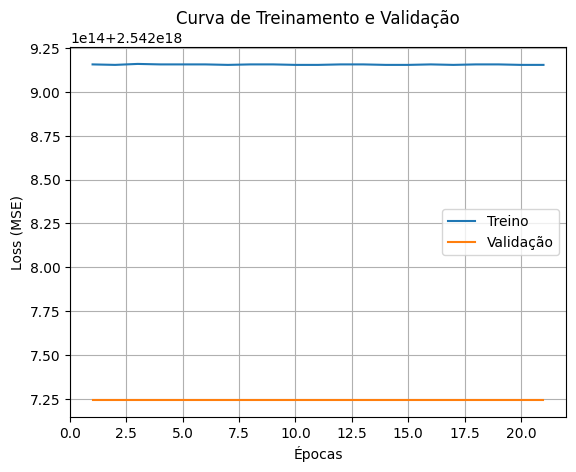

In [31]:
#GRÁFICO 1 - CURVA DE TREINO x VALIDAÇÃO

history_dict = history.history
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]

epochs = range(1, len(loss) + 1)

plt.figure()
plt.plot(epochs, loss, label="Treino")
plt.plot(epochs, val_loss, label="Validação")
plt.xlabel("Épocas")
plt.ylabel("Loss (MSE)")
plt.title("Curva de Treinamento e Validação")
plt.legend()
plt.grid(True)
plt.show()

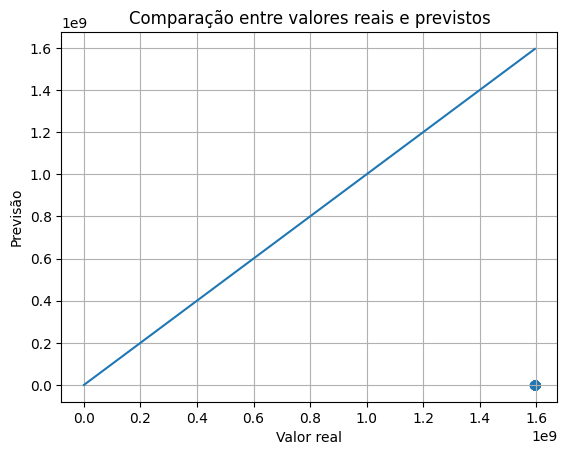

In [32]:
#GRÁFICO 2 - y_real x y_pred
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)
# linha de referência y = x
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Valor real")
plt.ylabel("Previsão")
plt.title("Comparação entre valores reais e previstos")
plt.grid(True)
plt.show()


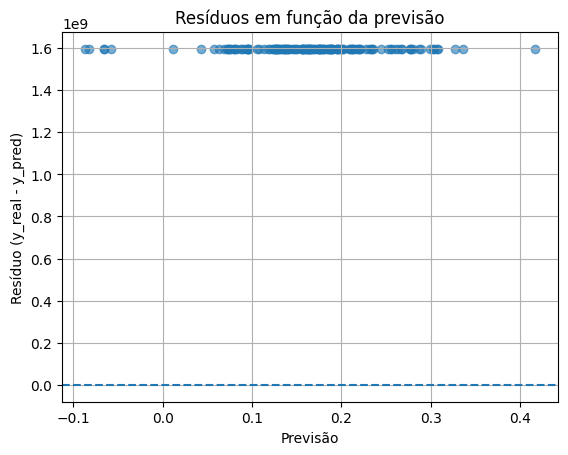

In [33]:
# GRÁFICO 3 - RESÍDUOS
residuos = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Previsão")
plt.ylabel("Resíduo (y_real - y_pred)")
plt.title("Resíduos em função da previsão")
plt.grid(True)
plt.show()